In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import hdbscan

TARGET_MMSI = [610107116, 273217380, 258035000]

# Pagrindiniai rugsėjo sample failai
D_PATH = Path("D_50_rugsejis.npy")
X_SAMPLE_PATH = Path("X_w50_rugsejis_sample.npy")
META_SAMPLE_PATH = Path("metadata_w50_rugsejis_sample.csv")
SAMPLE_IDX_PATH = Path("sample_idx_w50_rugsejis.npy")

# Išvesties failai
LABELS_RAW_PATH = Path("labels_hdbscan_50_rugsejis_sample_raw.npy")
LABELS_FINAL_PATH = Path("labels_hdbscan_50_rugsejis_sample_final.npy")
META_HDBSCAN_PATH = Path("metadata_w50_rugsejis_sample_hdbscan.csv")
REPS_PATH = Path("hdbscan_50_rugsejis_representatives.npz")

print("Target MMSI:", TARGET_MMSI)


Target MMSI: [610107116, 273217380, 258035000]


In [2]:
# Failų patikrinimas

required_files = [D_PATH, X_SAMPLE_PATH, META_SAMPLE_PATH, SAMPLE_IDX_PATH]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Nerastas failas: {path}")
    print(f"{path}: {path.stat().st_size / 1024**2:.2f} MB")


D_50_rugsejis.npy: 88.81 MB
X_w50_rugsejis_sample.npy: 5.52 MB
metadata_w50_rugsejis_sample.csv: 0.49 MB
sample_idx_w50_rugsejis.npy: 0.04 MB


In [3]:
# Duomenų užkrovimas

D = np.load(D_PATH, mmap_mode="r")
X_sample = np.load(X_SAMPLE_PATH, mmap_mode="r")
sample_meta = pd.read_csv(META_SAMPLE_PATH).reset_index(drop=True)
sample_idx = np.load(SAMPLE_IDX_PATH, allow_pickle=False)

print("D shape:", D.shape, "dtype:", D.dtype)
print("X_sample shape:", X_sample.shape, "dtype:", X_sample.dtype)
print("sample_meta shape:", sample_meta.shape)
print("sample_idx shape:", sample_idx.shape)

if D.shape[0] != D.shape[1]:
    raise ValueError("D turi būti kvadratinė matrica.")

if D.shape[0] != len(X_sample):
    raise ValueError("D ir X_sample ilgiai nesutampa.")

if len(sample_meta) != len(X_sample):
    raise ValueError("metadata ir X_sample ilgiai nesutampa.")

if len(sample_idx) != len(X_sample):
    raise ValueError("sample_idx ir X_sample ilgiai nesutampa.")

if "mmsi" not in sample_meta.columns:
    print("Turimi metadata stulpeliai:")
    print(sample_meta.columns.tolist())
    raise ValueError("metadata faile nerastas stulpelis 'mmsi'.")

sample_meta["mmsi"] = pd.to_numeric(sample_meta["mmsi"], errors="coerce").astype("Int64")
sample_meta["is_target_mmsi"] = sample_meta["mmsi"].isin(TARGET_MMSI)

print("\nTarget MMSI kiekiai sample:")
print(sample_meta.loc[sample_meta["is_target_mmsi"], "mmsi"].value_counts())


D shape: (4825, 4825) dtype: float32
X_sample shape: (4825, 50, 6) dtype: float32
sample_meta shape: (4825, 13)
sample_idx shape: (4825,)

Target MMSI kiekiai sample:
mmsi
610107116    70
258035000    59
273217380    55
Name: count, dtype: Int64


In [4]:
# HDBSCAN patogumui atstumų matricą konvertuojam į float64
# 4825 x 4825 matrica float64 formatu vis dar nėra didelė lokaliai.

masyvas = np.asarray(D, dtype=np.float64)
n = masyvas.shape[0]

print("masyvas shape:", masyvas.shape)
print("masyvas dtype:", masyvas.dtype)
print("min:", np.nanmin(masyvas))
print("max:", np.nanmax(masyvas))
print("ar visi skaičiai baigtiniai:", np.isfinite(masyvas).all())
print("maks. įstrižainės reikšmė:", np.abs(np.diag(masyvas)).max())


masyvas shape: (4825, 4825)
masyvas dtype: float64
min: 0.0
max: 154.08099365234375
ar visi skaičiai baigtiniai: True
maks. įstrižainės reikšmė: 0.0


In [17]:
# Parametrų paieška
# Ieškom varianto, kur nebūtų per daug triukšmo ir nebūtų vienas milžiniškas klasteris.

results = []

for min_size in [15, 20, 30, 50, 75, 100]:
    for min_samples in [1, 2, 3, 5, 8, 10, 15]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size,
            min_samples=min_samples,
            metric="precomputed",
            cluster_selection_method="eom"
        )

        labels_tmp = clusterer.fit_predict(masyvas)

        noise = int((labels_tmp == -1).sum())
        clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
        noise_pct = noise / n * 100

        counts = pd.Series(labels_tmp).value_counts()
        largest_cluster = int(counts.drop(index=-1, errors="ignore").max()) if clusters > 0 else 0
        largest_pct = largest_cluster / n * 100

        results.append({
            "min_cluster_size": min_size,
            "min_samples": min_samples,
            "clusters": clusters,
            "noise": noise,
            "noise_pct": noise_pct,
            "largest_cluster": largest_cluster,
            "largest_pct": largest_pct
        })

        marker = " ✓" if 3 <= noise_pct <= 10 else ""
        print(
            f"min_cluster_size={min_size:4d}, "
            f"min_samples={min_samples:3d} -> "
            f"klasterių: {clusters:3d}, "
            f"triukšmas: {noise:4d} ({noise_pct:5.1f}%), "
            f"didž. klasteris: {largest_pct:5.1f}%{marker}"
        )

param_results = pd.DataFrame(results)
param_results.sort_values(["noise_pct", "largest_pct"]).head(20)


min_cluster_size=  15, min_samples=  1 -> klasterių:  39, triukšmas: 3008 ( 62.3%), didž. klasteris:   9.2%
min_cluster_size=  15, min_samples=  2 -> klasterių:  34, triukšmas: 3130 ( 64.9%), didž. klasteris:   8.7%
min_cluster_size=  15, min_samples=  3 -> klasterių:  24, triukšmas: 2207 ( 45.7%), didž. klasteris:  39.9%
min_cluster_size=  15, min_samples=  5 -> klasterių:  25, triukšmas: 2273 ( 47.1%), didž. klasteris:  39.1%
min_cluster_size=  15, min_samples=  8 -> klasterių:  23, triukšmas: 2249 ( 46.6%), didž. klasteris:  39.8%
min_cluster_size=  15, min_samples= 10 -> klasterių:  23, triukšmas: 2330 ( 48.3%), didž. klasteris:  38.6%
min_cluster_size=  15, min_samples= 15 -> klasterių:  20, triukšmas: 2254 ( 46.7%), didž. klasteris:  40.1%
min_cluster_size=  20, min_samples=  1 -> klasterių:  30, triukšmas: 3003 ( 62.2%), didž. klasteris:   9.2%
min_cluster_size=  20, min_samples=  2 -> klasterių:  30, triukšmas: 3081 ( 63.9%), didž. klasteris:   8.7%
min_cluster_size=  20, min_s

,min_cluster_size,min_samples,clusters,noise,noise_pct,largest_cluster,largest_pct
34,75,15,2,1798,37.264249,1935,40.103627
41,100,15,2,1798,37.264249,1935,40.103627
25,50,8,2,1822,37.761658,1920,39.792746
40,100,10,2,1900,39.378238,1862,38.590674
11,20,8,16,2156,44.683938,1920,39.792746
18,30,8,12,2163,44.829016,1920,39.792746
26,50,10,7,2173,45.036269,1862,38.590674
9,20,3,19,2176,45.098446,1926,39.917098
27,50,15,8,2189,45.367876,1935,40.103627
13,20,15,15,2194,45.471503,1935,40.103627


In [43]:
# Papildomas cluster_selection_epsilon pabandymas pagal atstumų kvantilius

upper = masyvas[np.triu_indices(n, k=1)]
upper = upper[np.isfinite(upper)]

eps_values = [0.0]
eps_values += list(map(float, np.quantile(upper, [0.001, 0.002, 0.005, 0.01, 0.02])))

for eps in eps_values:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=20,
        min_samples=8,
        metric="precomputed",
        cluster_selection_method="eom",
        cluster_selection_epsilon=float(eps),
        allow_single_cluster=False
    )

    labels_tmp = clusterer.fit_predict(masyvas)
    noise = int((labels_tmp == -1).sum())
    clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    noise_pct = noise / n * 100

    print(f"eps={eps:.6f} -> klasterių: {clusters:3d}, triukšmas: {noise:4d} ({noise_pct:.1f}%)")


eps=0.000000 -> klasterių:  16, triukšmas: 2156 (44.7%)
eps=0.823391 -> klasterių:   9, triukšmas: 2108 (43.7%)
eps=1.446759 -> klasterių:   2, triukšmas: 1822 (37.8%)
eps=2.573402 -> klasterių:   2, triukšmas: 1822 (37.8%)
eps=3.836410 -> klasterių:   2, triukšmas: 1822 (37.8%)
eps=5.498463 -> klasterių:   2, triukšmas: 1822 (37.8%)


In [5]:
# Galutinis HDBSCAN modelis

MIN_CLUSTER_SIZE = 20
MIN_SAMPLES = 8
CLUSTER_SELECTION_EPSILON = 0.0

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="precomputed",
    cluster_selection_method="eom",
    cluster_selection_epsilon=CLUSTER_SELECTION_EPSILON,
    allow_single_cluster=False
)

labels_hdbscan_raw = clusterer.fit_predict(masyvas)

raw_noise = int((labels_hdbscan_raw == -1).sum())
raw_clusters = len(set(labels_hdbscan_raw)) - (1 if -1 in labels_hdbscan_raw else 0)

print(f"Raw HDBSCAN -> klasterių: {raw_clusters}, triukšmas: {raw_noise} ({raw_noise / n * 100:.1f}%)")

np.save(LABELS_RAW_PATH, labels_hdbscan_raw)
print("Išsaugota:", LABELS_RAW_PATH)

Raw HDBSCAN -> klasterių: 16, triukšmas: 2156 (44.7%)
Išsaugota: labels_hdbscan_50_rugsejis_sample_raw.npy


In [7]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=8,
    metric="precomputed",
    cluster_selection_method="eom",
    cluster_selection_epsilon=0.0
)

labels_hdbscan = clusterer.fit_predict(masyvas)

# Čia paliekam raw HDBSCAN rezultatą
original_labels = labels_hdbscan.copy()
final_labels = labels_hdbscan.copy()

n = len(final_labels)

n_noise = np.sum(final_labels == -1)
n_clusters = len(set(final_labels) - {-1})

print(f"HDBSCAN klasterių: {n_clusters}")
print(f"HDBSCAN noise: {n_noise} ({n_noise / n * 100:.1f}%)")

HDBSCAN klasterių: 16
HDBSCAN noise: 2156 (44.7%)


In [8]:
cluster_reps = {}

# -1 praleidžiam, nes noise nėra tikras klasteris
for c in sorted(set(final_labels) - {-1}):
    members = np.where(final_labels == c)[0]
    
    if len(members) <= 3:
        cluster_reps[c] = members.tolist()
        continue
    
    D = masyvas[np.ix_(members, members)]
    sums = D.sum(axis=1)
    
    medoid_pos = np.argmin(sums)
    medoid_idx = members[medoid_pos]
    
    order = np.argsort(D[medoid_pos])
    nearest_local = [members[i] for i in order if members[i] != medoid_idx]
    
    reps = [medoid_idx] + nearest_local[:2]
    cluster_reps[c] = reps

print("Klasterių su reprezentantais:", len(cluster_reps))
print("Reprezentantų kiekis:", sum(len(v) for v in cluster_reps.values()))

Klasterių su reprezentantais: 16
Reprezentantų kiekis: 48


In [9]:
train_best_dists = []

for i in range(len(final_labels)):
    c = final_labels[i]
    
    # Noise nenaudojam threshold skaičiavimui
    if c == -1:
        continue
    
    reps = cluster_reps[c]
    dists = [masyvas[i, r] for r in reps]
    train_best_dists.append(min(dists))

train_best_dists = np.array(train_best_dists)

threshold = float(np.quantile(train_best_dists, 0.80))

print("Threshold skaičiuotas iš:", len(train_best_dists), "ne-noise sample sekų")
print("Naudojamas slenkstis:", threshold)

Threshold skaičiuotas iš: 2669 ne-noise sample sekų
Naudojamas slenkstis: 27.22718505859375


In [10]:
new_sequences = np.load("X_w50_remaining.npy", allow_pickle=False)
print(type(new_sequences))
print(new_sequences.shape)
print(new_sequences.dtype)
subset_sequences = np.load("X_w50_rugsejis_sample.npy", allow_pickle=False)
print(type(subset_sequences))
print(subset_sequences.shape)
print(subset_sequences.dtype)

<class 'numpy.ndarray'>
(41552, 50, 6)
float32
<class 'numpy.ndarray'>
(4825, 50, 6)
float32


In [35]:
print(X.shape)

(46377, 50, 6)


In [11]:
import numpy as np
from tslearn.metrics import cdist_dtw

# 1. Surenkam visus klasterių reprezentantus
# -1 neimam, nes tai triukšmas, ne tikras klasteris
rep_indices = []
rep_clusters = []

for c, reps in cluster_reps.items():
    if c == -1:
        continue

    for r in reps:
        rep_indices.append(r)
        rep_clusters.append(c)

rep_indices = np.array(rep_indices)
rep_clusters = np.array(rep_clusters)

representative_sequences = subset_sequences[rep_indices].astype(np.float64)

print("Reprezentantų kiekis:", len(representative_sequences))
print("Naujų sekų kiekis:", len(new_sequences))
print("Iš viso DTW atstumų:", len(new_sequences) * len(representative_sequences))

Reprezentantų kiekis: 48
Naujų sekų kiekis: 41552
Iš viso DTW atstumų: 1994496


In [12]:
assigned_labels = []
assigned_dists = []

chunk_size = 500

for start in range(0, len(new_sequences), chunk_size):
    end = min(start + chunk_size, len(new_sequences))

    chunk = new_sequences[start:end].astype(np.float64)

    D_chunk = cdist_dtw(
        chunk,
        representative_sequences,
        n_jobs=-1
    )

    best_rep_pos = np.argmin(D_chunk, axis=1)
    best_dists = D_chunk[np.arange(len(chunk)), best_rep_pos]
    best_clusters = rep_clusters[best_rep_pos]

    labels_chunk = np.where(best_dists <= threshold, best_clusters, -1)

    assigned_labels.extend(labels_chunk)
    assigned_dists.extend(best_dists)

    print(f"Baigta: {end}/{len(new_sequences)}")

assigned_labels = np.array(assigned_labels)
assigned_dists = np.array(assigned_dists)

print("Triukšmas:", np.sum(assigned_labels == -1))
print("Triukšmo procentas:", np.mean(assigned_labels == -1) * 100)

Baigta: 500/41552
Baigta: 1000/41552
Baigta: 1500/41552
Baigta: 2000/41552
Baigta: 2500/41552
Baigta: 3000/41552
Baigta: 3500/41552
Baigta: 4000/41552
Baigta: 4500/41552
Baigta: 5000/41552
Baigta: 5500/41552
Baigta: 6000/41552
Baigta: 6500/41552
Baigta: 7000/41552
Baigta: 7500/41552
Baigta: 8000/41552
Baigta: 8500/41552
Baigta: 9000/41552
Baigta: 9500/41552
Baigta: 10000/41552
Baigta: 10500/41552
Baigta: 11000/41552
Baigta: 11500/41552
Baigta: 12000/41552
Baigta: 12500/41552
Baigta: 13000/41552
Baigta: 13500/41552
Baigta: 14000/41552
Baigta: 14500/41552
Baigta: 15000/41552
Baigta: 15500/41552
Baigta: 16000/41552
Baigta: 16500/41552
Baigta: 17000/41552
Baigta: 17500/41552
Baigta: 18000/41552
Baigta: 18500/41552
Baigta: 19000/41552
Baigta: 19500/41552
Baigta: 20000/41552
Baigta: 20500/41552
Baigta: 21000/41552
Baigta: 21500/41552
Baigta: 22000/41552
Baigta: 22500/41552
Baigta: 23000/41552
Baigta: 23500/41552
Baigta: 24000/41552
Baigta: 24500/41552
Baigta: 25000/41552
Baigta: 25500/41552


aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa

In [13]:
# Klasterių dydžiai

cluster_sizes = (
    pd.Series(assigned_labels, name="cluster")
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = ["cluster", "size"]
cluster_sizes["pct"] = cluster_sizes["size"] / len(assigned_labels) * 100
cluster_sizes["cluster_name"] = cluster_sizes["cluster"].apply(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)

cluster_sizes = cluster_sizes[["cluster_name", "cluster", "size", "pct"]]

print(cluster_sizes.to_string(index=False))


cluster_name  cluster  size       pct
       noise       -1  1243  2.991432
   cluster_0        0 10483 25.228629
   cluster_1        1  1157  2.784463
   cluster_2        2  2030  4.885445
   cluster_3        3  2323  5.590585
   cluster_4        4  3746  9.015210
   cluster_5        5  1484  3.571429
   cluster_6        6  1261  3.034752
   cluster_7        7  3733  8.983924
   cluster_8        8  1771  4.262129
   cluster_9        9  2164  5.207932
  cluster_10       10  1678  4.038313
  cluster_11       11  3040  7.316134
  cluster_12       12  1406  3.383712
  cluster_13       13  1019  2.452349
  cluster_14       14  1206  2.902387
  cluster_15       15  1808  4.351174


In [29]:
# Pridedam klasterius prie sample metadata ir išsaugom

sample_meta_hdbscan = sample_meta.copy()
sample_meta_hdbscan["final_cluster"] = final_labels

ship_sample = sample_meta_hdbscan[
    sample_meta_hdbscan["mmsi"].astype(str) == str(258035000)
]
# 610107116, 273217380, 258035000
display(ship_sample[[
    "sequence_id",
    "mmsi",
    "start_time",
    "end_time",
    "final_cluster"
]])

,sequence_id,mmsi,start_time,end_time,final_cluster
2759,27328,258035000,2025-09-21 00:10:00,2025-09-21 01:48:00,0
2760,27329,258035000,2025-09-21 01:00:00,2025-09-21 02:38:00,0
2761,27330,258035000,2025-09-21 01:50:00,2025-09-21 03:28:00,0
2762,27331,258035000,2025-09-21 07:52:00,2025-09-21 09:30:00,0
2763,27332,258035000,2025-09-21 08:42:00,2025-09-21 10:20:00,0
2764,27333,258035000,2025-09-21 09:32:00,2025-09-21 11:10:00,0
2765,27334,258035000,2025-09-21 10:22:00,2025-09-21 12:00:00,0
2766,27335,258035000,2025-09-21 11:12:00,2025-09-21 12:50:00,0
2767,27336,258035000,2025-09-21 12:02:00,2025-09-21 13:40:00,0
2768,27337,258035000,2025-09-21 12:52:00,2025-09-21 14:30:00,0


c:\Users\minvy\AppData\Local\Programs\Python\Python314\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


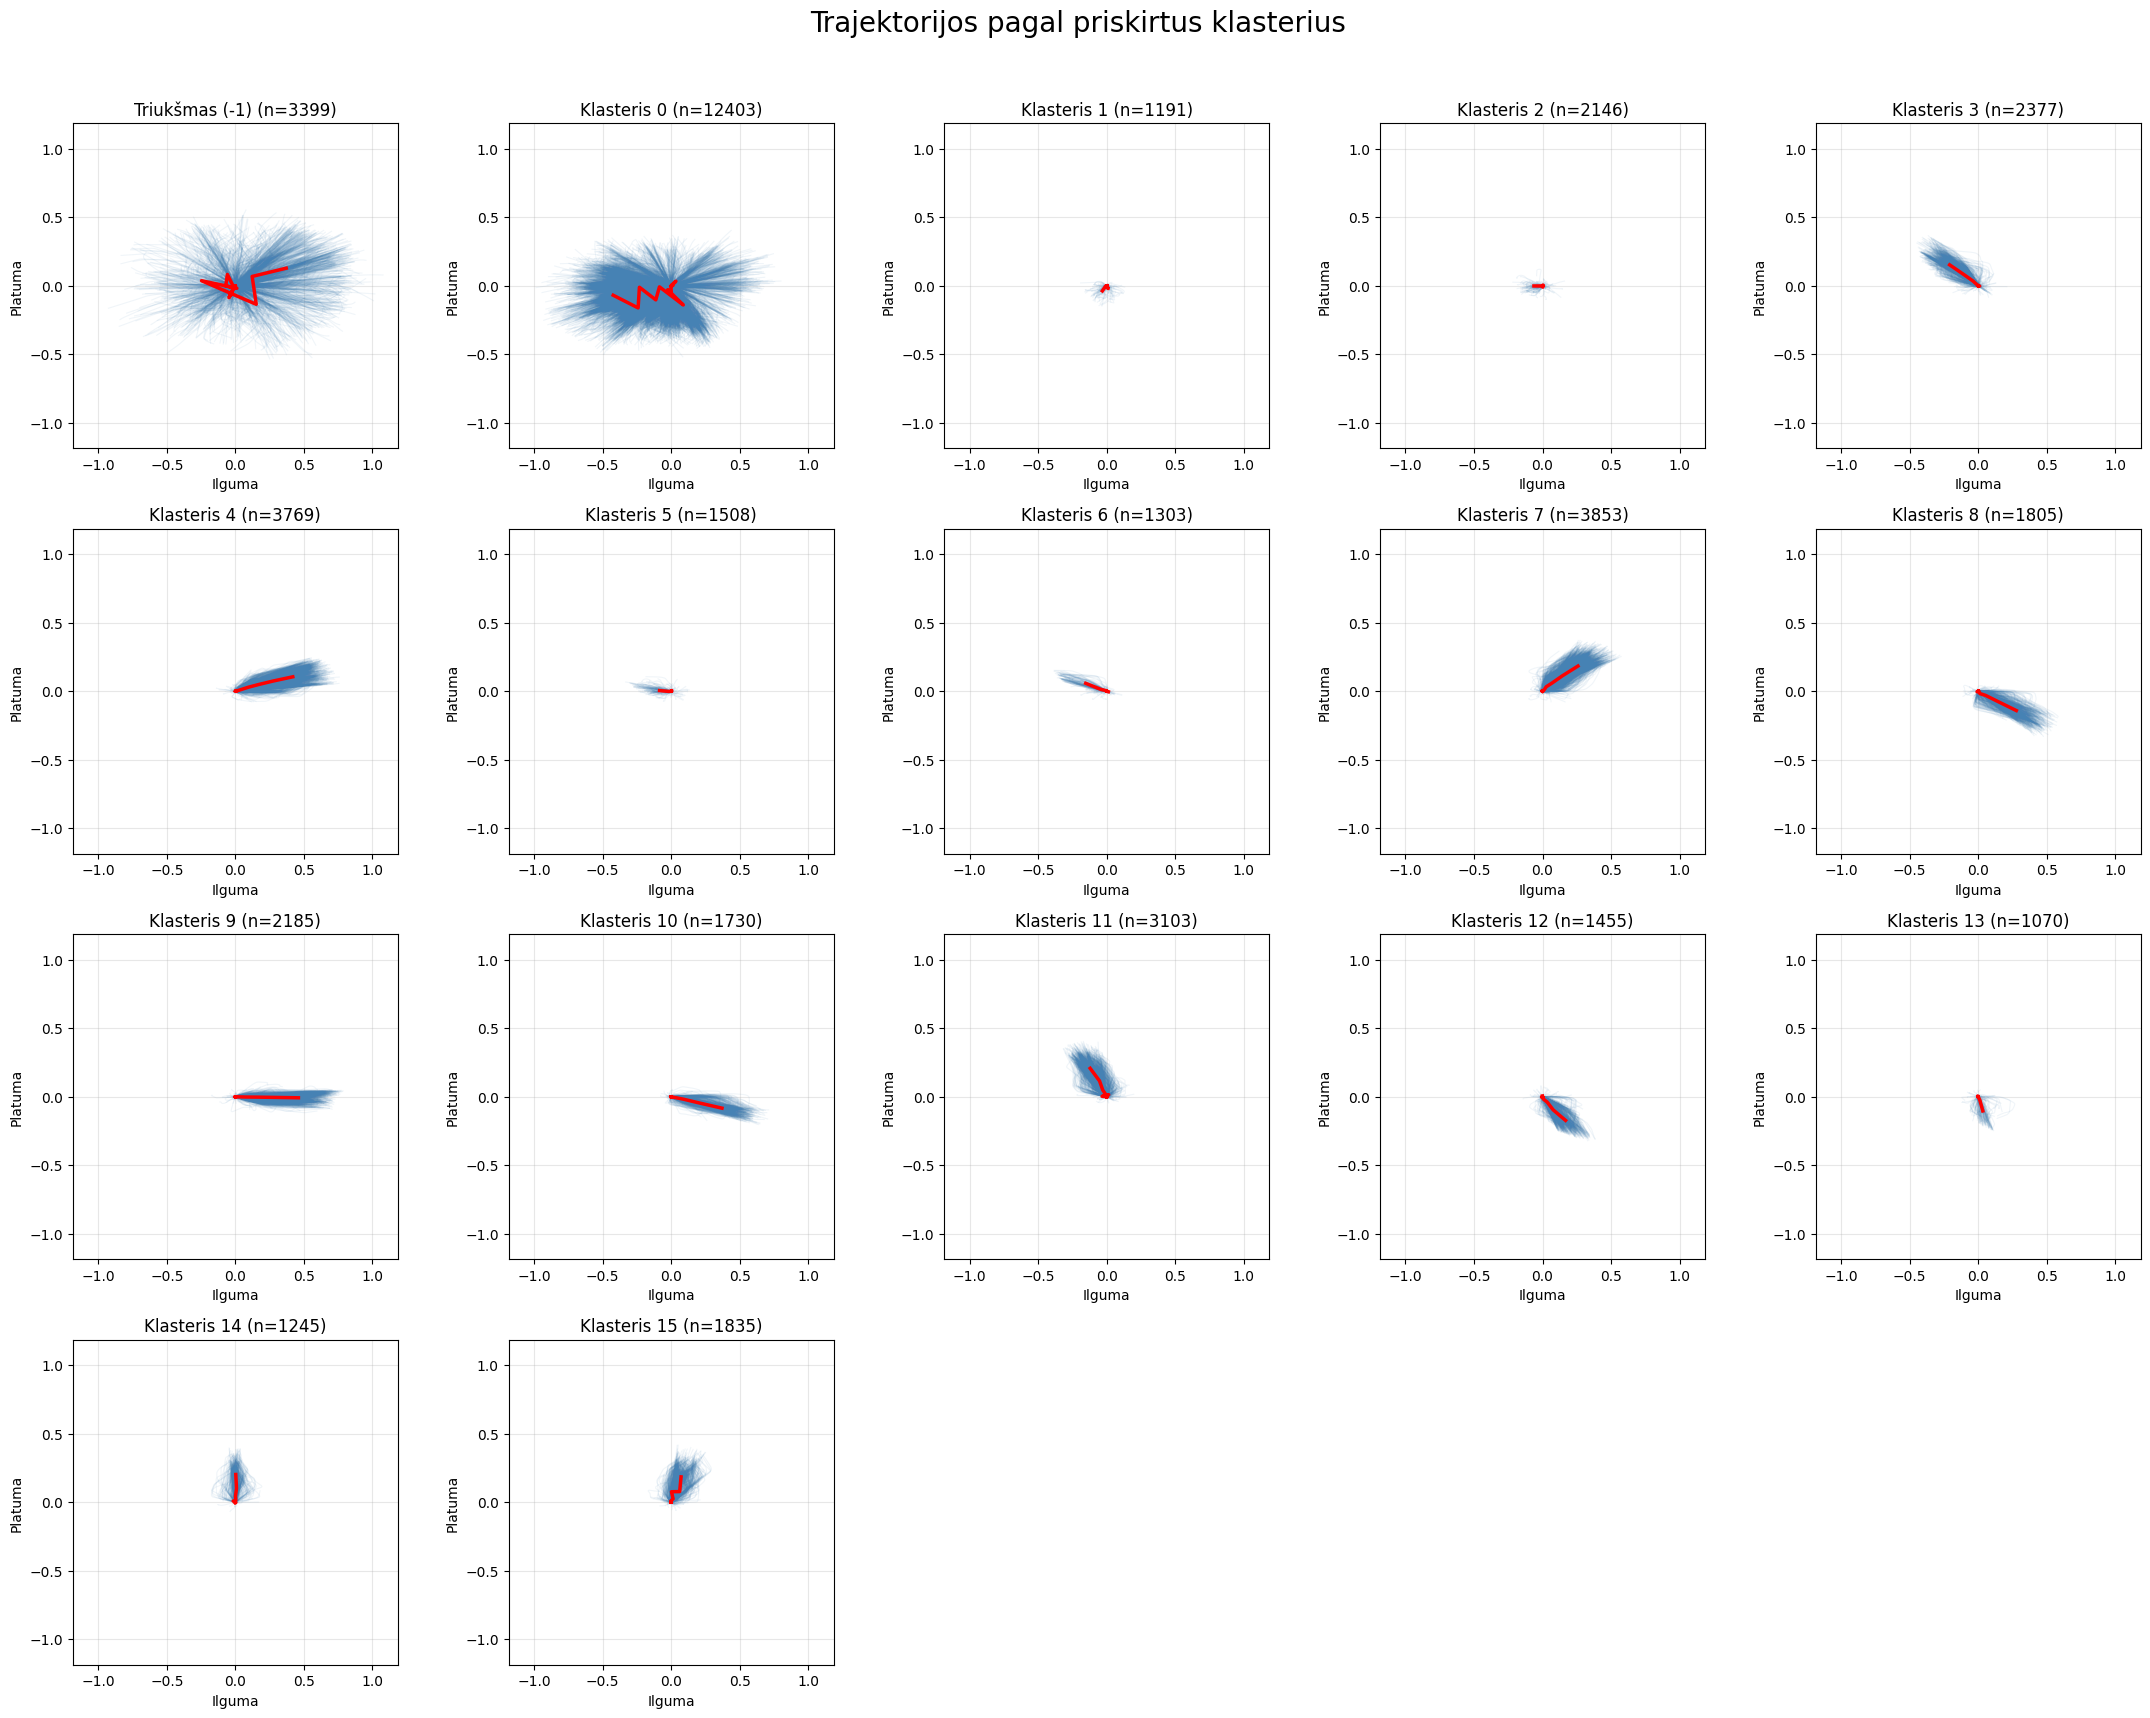

In [14]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tslearn.barycenters import dtw_barycenter_averaging

# Braižymui naudojam RAW reliatyvias koordinates
X_raw = np.load("X_w50_raw.npy", allow_pickle=False)
sample_idx = np.load("sample_idx_w50_rugsejis.npy", allow_pickle=False)

all_idx = np.arange(len(X_raw))
remaining_idx = np.setdiff1d(all_idx, sample_idx)


labels_full = np.full(len(X_raw), -999, dtype=int)

# sample dalis
labels_full[sample_idx] = final_labels

# remaining dalis
labels_full[remaining_idx] = assigned_labels

# pilnos trajektorijos
X = X_raw.astype(np.float64)
labels = labels_full

# sanity check
if np.any(labels == -999):
    raise ValueError("Ne visiems įrašams priskirti labeliai.")

if len(X) != len(labels):
    raise ValueError("KLAIDA: X ir labels ilgiai nesutampa.")

# Bendros ašių ribos visiems klasteriams
all_y_global = X[:, :, 0].ravel()
all_x_global = X[:, :, 1].ravel()

valid_global = np.isfinite(all_x_global) & np.isfinite(all_y_global)

all_x_global = all_x_global[valid_global]
all_y_global = all_y_global[valid_global]

xmin, xmax = np.min(all_x_global), np.max(all_x_global)
ymin, ymax = np.min(all_y_global), np.max(all_y_global)

max_abs = max(abs(xmin), abs(xmax), abs(ymin), abs(ymax))
pad = max(max_abs * 0.1, 0.001)

xlim_global = (-max_abs - pad, max_abs + pad)
ylim_global = (-max_abs - pad, max_abs + pad)

# Klasteriai
unique_clusters = sorted(np.unique(labels))

n_clusters = len(unique_clusters)
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 4.2 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)

rng = np.random.default_rng(42)

for plot_i, k in enumerate(unique_clusters):
    ax = axes[plot_i]

    idx = np.where(labels == k)[0]

    # Braižom trajektorijas
    for i in idx:
        coords = X[i]

        y = coords[:, 0]
        x = coords[:, 1]

        valid = np.isfinite(x) & np.isfinite(y)

        if valid.any():
            ax.plot(
                x[valid],
                y[valid],
                color="steelblue",
                alpha=0.08,
                linewidth=0.8
            )

    # DTW barycentras
    if len(idx) > 0:
        if len(idx) > 200:
            idx_for_bary = rng.choice(idx, size=200, replace=False)
        else:
            idx_for_bary = idx

        cluster_series = X[idx_for_bary, :, :2]

        barycenter = dtw_barycenter_averaging(
            cluster_series,
            max_iter=20
        )

        valid_bary = (
            np.isfinite(barycenter[:, 0])
            & np.isfinite(barycenter[:, 1])
        )

        ax.plot(
            barycenter[valid_bary, 1],
            barycenter[valid_bary, 0],
            color="red",
            linewidth=2.5
        )

    # Vienodos ašys visiems klasteriams
    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)

    # Pavadinimai
    title_name = "Triukšmas (-1)" if k == -1 else f"Klasteris {k}"
    ax.set_title(f"{title_name} (n={len(idx)})")

    # Ašių pavadinimai ant kiekvieno subplot'o
    ax.set_xlabel("Ilguma")
    ax.set_ylabel("Platuma")

    # Rodom abi ašis ir jų skaičius ant kiekvieno subplot'o
    ax.tick_params(
        axis="both",
        which="both",
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True
    )

    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

# Ištrinam tuščius subplotus
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Trajektorijos pagal priskirtus klasterius",
    fontsize=20,
    y=1.02
)

plt.tight_layout()
plt.show()

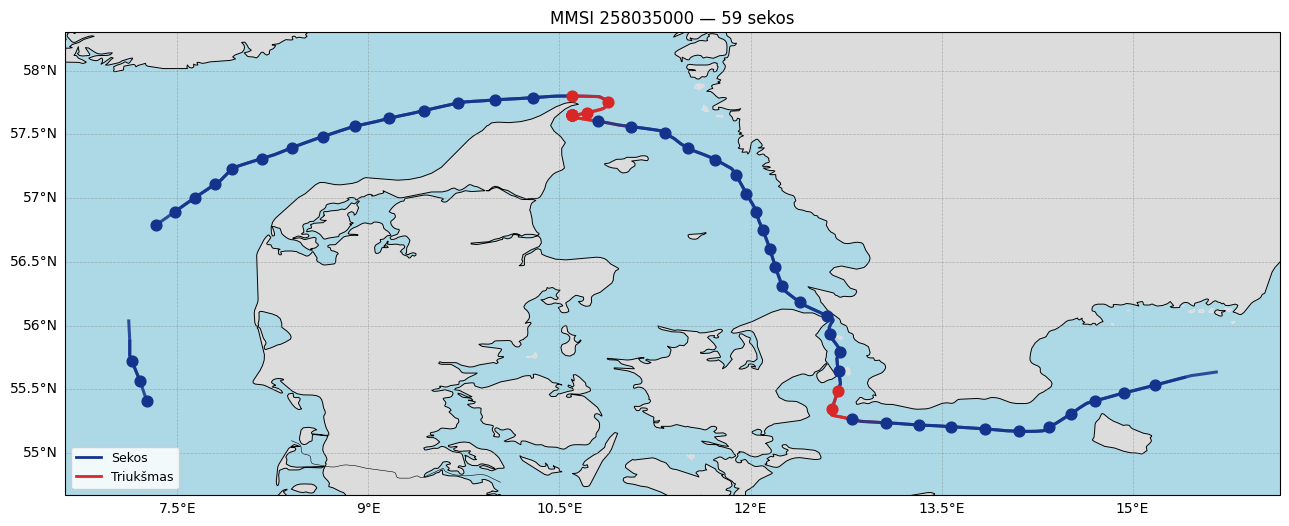

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Įkeliame duomenis ───────────────────────────────────────────────────────
X_original  = np.load("X_w50_original.npy", allow_pickle=False)
sample_idx  = np.load("sample_idx_w50_rugsejis.npy", allow_pickle=False)
sample_meta = pd.read_csv("metadata_w50_rugsejis_sample.csv").reset_index(drop=True)

target_mmsi = 258035000

# ── Tik sample sekos ────────────────────────────────────────────────────────
sample_meta["final_cluster"] = final_labels

target_rows   = sample_meta[sample_meta["mmsi"].astype(str) == str(target_mmsi)]
target_global = sample_idx[target_rows.index.to_numpy()]
target_labels = target_rows["final_cluster"].to_numpy()

# ── Koordinatės ir extent ───────────────────────────────────────────────────
all_lats, all_lons = [], []
for gi in target_global:
    lat_i = X_original[gi, :, 0]
    lon_i = X_original[gi, :, 1]
    valid = np.isfinite(lat_i) & np.isfinite(lon_i)
    all_lats.append(lat_i[valid])
    all_lons.append(lon_i[valid])

all_lats_cat = np.concatenate(all_lats)
all_lons_cat = np.concatenate(all_lons)

PAD     = 0.5
lon_min = all_lons_cat.min() - PAD
lon_max = all_lons_cat.max() + PAD
lat_min = all_lats_cat.min() - PAD
lat_max = all_lats_cat.max() + PAD

# ── Žemėlapis ───────────────────────────────────────────────────────────────
def get_color(lbl):
    return (0.85, 0.15, 0.15, 1.0) if lbl == -1 else (0.08, 0.2, 0.55, 1.0)

fig = plt.figure(figsize=(13, 10))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN,     facecolor="lightblue")
ax.add_feature(cfeature.LAND,      facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4)

plotted = set()
for gi, lbl, lats, lons in zip(target_global, target_labels, all_lats, all_lons):
    if len(lats) == 0:
        continue
    color   = get_color(lbl)
    leg_key = "Triukšmas" if lbl == -1 else "Sekos"
    ax.plot(lons, lats, color=color, linewidth=2.2, alpha=0.85,
            transform=ccrs.PlateCarree(), zorder=4,
            label=leg_key if leg_key not in plotted else "_nolegend_")
    ax.scatter(lons[0],  lats[0],  color=color, s=60, marker="o",
               zorder=5, transform=ccrs.PlateCarree())
    plotted.add(leg_key)

gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                  color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"MMSI {target_mmsi} — {len(target_global)} sekos")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85, handles=[
    plt.Line2D([0],[0], color=(0.08,0.2,0.55), lw=2, label="Sekos"),
    plt.Line2D([0],[0], color=(0.85,0.15,0.15), lw=2, label="Triukšmas"),
])
plt.tight_layout()
plt.show()

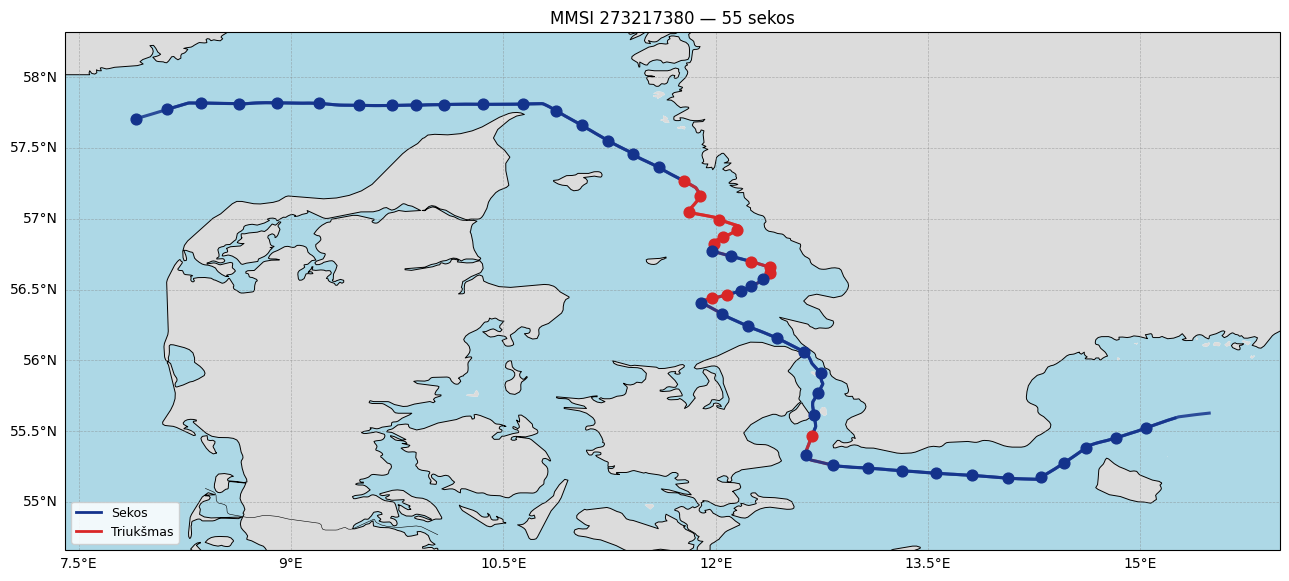

In [16]:
target_mmsi = 273217380

# ── Tik sample sekos ────────────────────────────────────────────────────────
sample_meta["final_cluster"] = final_labels

target_rows   = sample_meta[sample_meta["mmsi"].astype(str) == str(target_mmsi)]
target_global = sample_idx[target_rows.index.to_numpy()]
target_labels = target_rows["final_cluster"].to_numpy()

# ── Koordinatės ir extent ───────────────────────────────────────────────────
all_lats, all_lons = [], []
for gi in target_global:
    lat_i = X_original[gi, :, 0]
    lon_i = X_original[gi, :, 1]
    valid = np.isfinite(lat_i) & np.isfinite(lon_i)
    all_lats.append(lat_i[valid])
    all_lons.append(lon_i[valid])

all_lats_cat = np.concatenate(all_lats)
all_lons_cat = np.concatenate(all_lons)

PAD     = 0.5
lon_min = all_lons_cat.min() - PAD
lon_max = all_lons_cat.max() + PAD
lat_min = all_lats_cat.min() - PAD
lat_max = all_lats_cat.max() + PAD

# ── Žemėlapis ───────────────────────────────────────────────────────────────
def get_color(lbl):
    return (0.85, 0.15, 0.15, 1.0) if lbl == -1 else (0.08, 0.2, 0.55, 1.0)

fig = plt.figure(figsize=(13, 10))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN,     facecolor="lightblue")
ax.add_feature(cfeature.LAND,      facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4)

plotted = set()
for gi, lbl, lats, lons in zip(target_global, target_labels, all_lats, all_lons):
    if len(lats) == 0:
        continue
    color   = get_color(lbl)
    leg_key = "Triukšmas" if lbl == -1 else "Sekos"
    ax.plot(lons, lats, color=color, linewidth=2.2, alpha=0.85,
            transform=ccrs.PlateCarree(), zorder=4,
            label=leg_key if leg_key not in plotted else "_nolegend_")
    ax.scatter(lons[0],  lats[0],  color=color, s=60, marker="o",
               zorder=5, transform=ccrs.PlateCarree())
    plotted.add(leg_key)

gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                  color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"MMSI {target_mmsi} — {len(target_global)} sekos")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85, handles=[
    plt.Line2D([0],[0], color=(0.08,0.2,0.55), lw=2, label="Sekos"),
    plt.Line2D([0],[0], color=(0.85,0.15,0.15), lw=2, label="Triukšmas"),
])
plt.tight_layout()
plt.show()

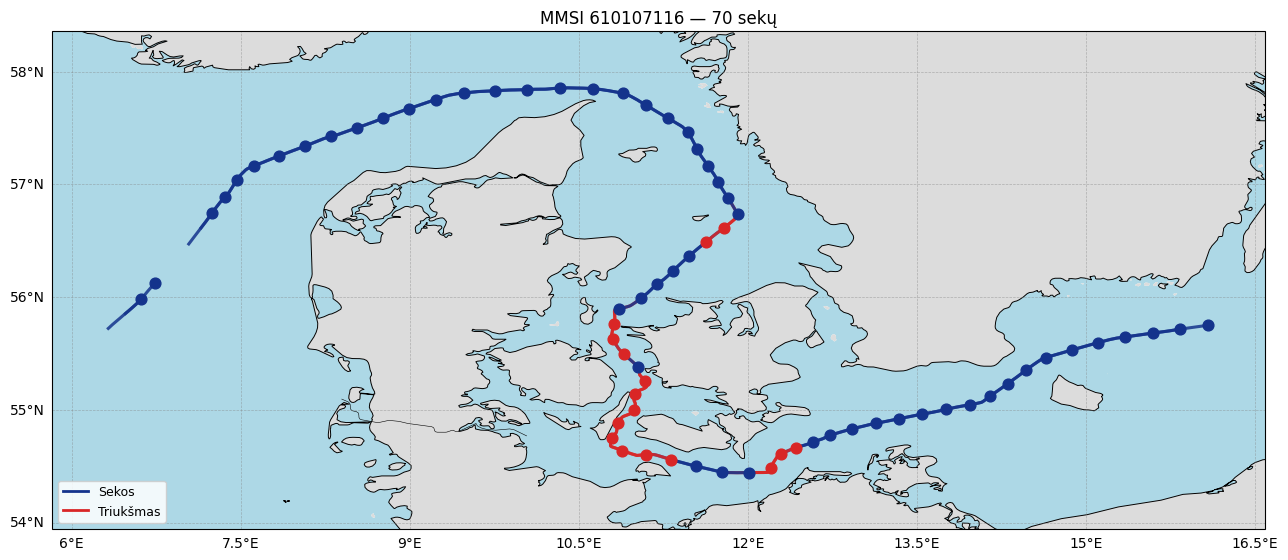

In [75]:
target_mmsi = 610107116

# ── Tik sample sekos ────────────────────────────────────────────────────────
sample_meta["final_cluster"] = final_labels

target_rows   = sample_meta[sample_meta["mmsi"].astype(str) == str(target_mmsi)]
target_global = sample_idx[target_rows.index.to_numpy()]
target_labels = target_rows["final_cluster"].to_numpy()

# ── Koordinatės ir extent ───────────────────────────────────────────────────
all_lats, all_lons = [], []
for gi in target_global:
    lat_i = X_original[gi, :, 0]
    lon_i = X_original[gi, :, 1]
    valid = np.isfinite(lat_i) & np.isfinite(lon_i)
    all_lats.append(lat_i[valid])
    all_lons.append(lon_i[valid])

all_lats_cat = np.concatenate(all_lats)
all_lons_cat = np.concatenate(all_lons)

PAD     = 0.5
lon_min = all_lons_cat.min() - PAD
lon_max = all_lons_cat.max() + PAD
lat_min = all_lats_cat.min() - PAD
lat_max = all_lats_cat.max() + PAD

# ── Žemėlapis ───────────────────────────────────────────────────────────────
def get_color(lbl):
    return (0.85, 0.15, 0.15, 1.0) if lbl == -1 else (0.08, 0.2, 0.55, 1.0)

fig = plt.figure(figsize=(13, 10))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN,     facecolor="lightblue")
ax.add_feature(cfeature.LAND,      facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4)

plotted = set()
for gi, lbl, lats, lons in zip(target_global, target_labels, all_lats, all_lons):
    if len(lats) == 0:
        continue
    color   = get_color(lbl)
    leg_key = "Triukšmas" if lbl == -1 else "Sekos"
    ax.plot(lons, lats, color=color, linewidth=2.2, alpha=0.85,
            transform=ccrs.PlateCarree(), zorder=4,
            label=leg_key if leg_key not in plotted else "_nolegend_")
    ax.scatter(lons[0],  lats[0],  color=color, s=60, marker="o",
               zorder=5, transform=ccrs.PlateCarree())
    plotted.add(leg_key)

gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                  color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"MMSI {target_mmsi} — {len(target_global)} sekų")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85, handles=[
    plt.Line2D([0],[0], color=(0.08,0.2,0.55), lw=2, label="Sekos"),
    plt.Line2D([0],[0], color=(0.85,0.15,0.15), lw=2, label="Triukšmas"),
])
plt.tight_layout()
plt.show()

---